In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
l5_df = pd.read_csv("Landsat5_Metadata_Export.csv")

l7_df = pd.read_csv("Landsat7_Metadata_Export.csv")

In [4]:
l5_df['date'] = pd.to_datetime(l5_df['date'])
l7_df['date'] = pd.to_datetime(l7_df['date'])


In [5]:
l5_df['tile_id'] = l5_df['WRS_PATH'].astype(int).astype(str) + '-' + l5_df['WRS_ROW'].astype(int).astype(str)

l7_df['tile_id'] = l7_df['WRS_PATH'].astype(int).astype(str) + '-' + l7_df['WRS_ROW'].astype(int).astype(str)


In [6]:
(l5_df['CLOUD_COVER'] == -1).sum()

np.int64(0)

In [7]:
l5_df["CLOUDLESS"] = 100 - l5_df['CLOUD_COVER']

# add month and year col
l5_df["month"] = l5_df['date'].dt.month
l5_df["year"] = l5_df['date'].dt.year

l7_df["CLOUDLESS"] = 100 - l7_df['CLOUD_COVER']

# add month and year col
l7_df["month"] = l7_df['date'].dt.month
l7_df["year"] = l7_df['date'].dt.year

In [8]:
import seaborn as sns
import matplotlib.dates as mdates

In [9]:
# 1. Set the high-level theme
sns.set_theme(style="whitegrid", font="sans-serif", rc={'figure.figsize':(25,10)})

# 2. Configure specific aesthetics
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1.5})

# 3. Choose a color palette (Set2 is great for distinct tile IDs)
palette = sns.color_palette("Set2")

<Axes: xlabel='CLOUD_COVER', ylabel='Percent'>

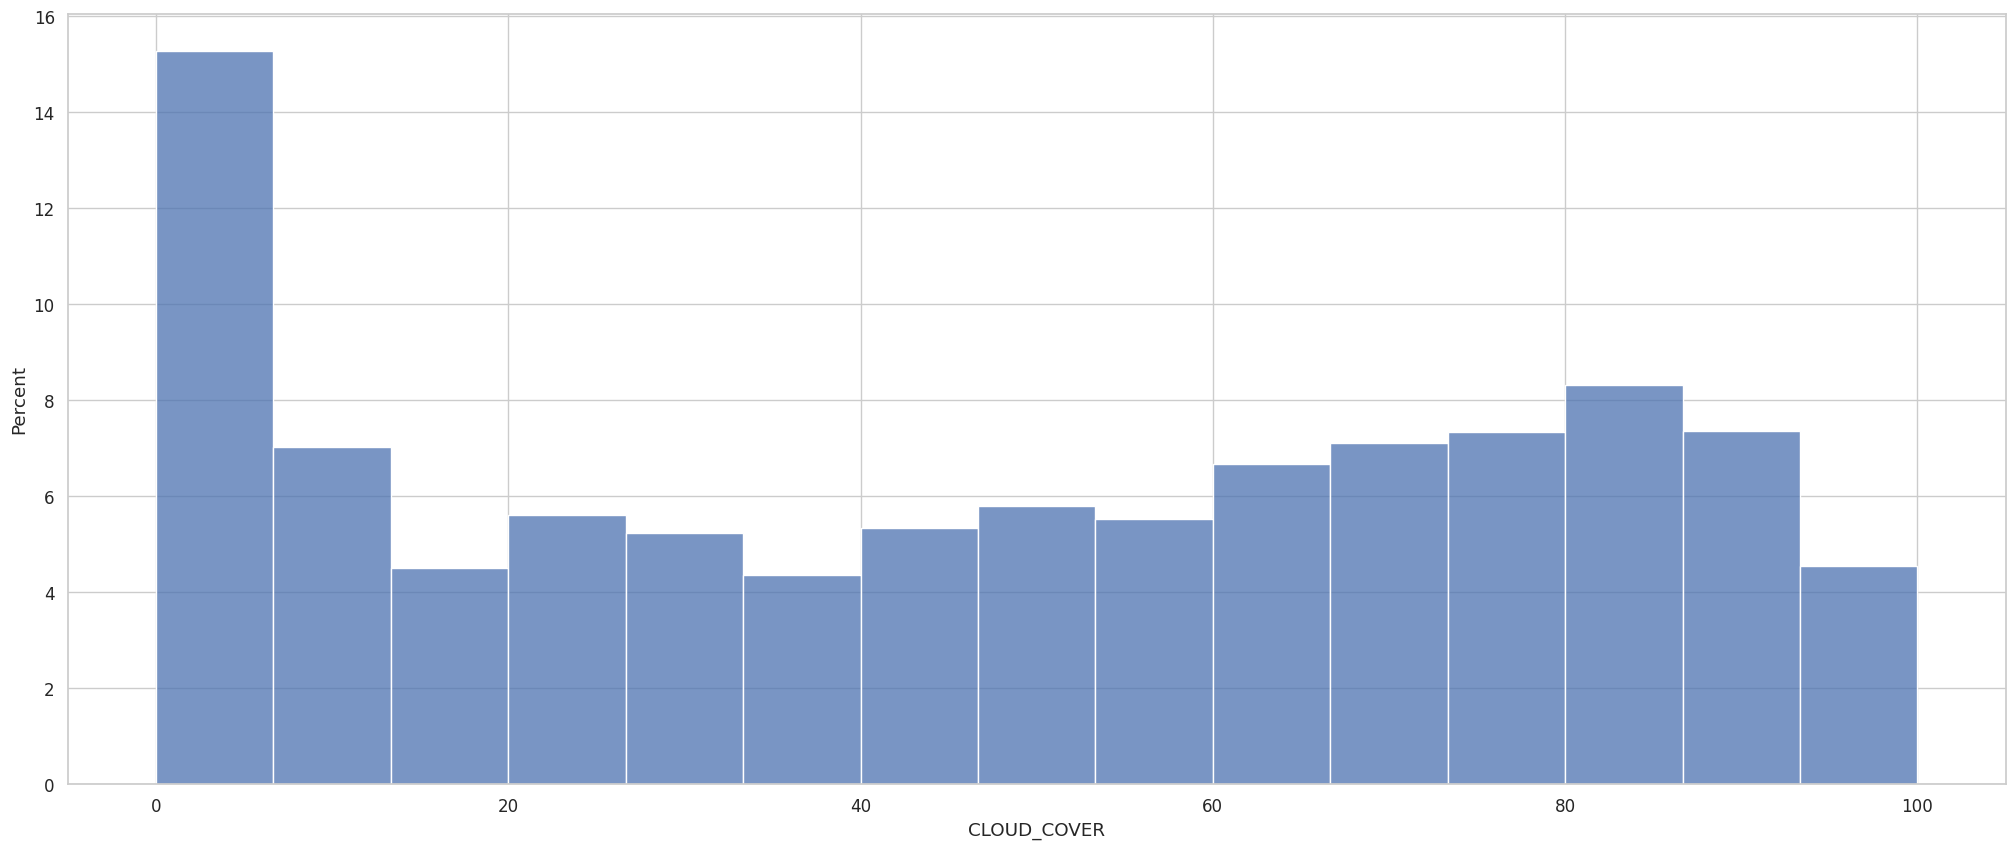

In [10]:
sns.histplot(data=l5_df, x='CLOUD_COVER', stat='percent')

In [12]:
custom_palette = sns.blend_palette(["#d3d3d3", "#95a5a6", "#f1c40f"], as_cmap=True)

Text(0.5, 1.0, 'Cloudless (> 80 % clear sky) observations per scene')

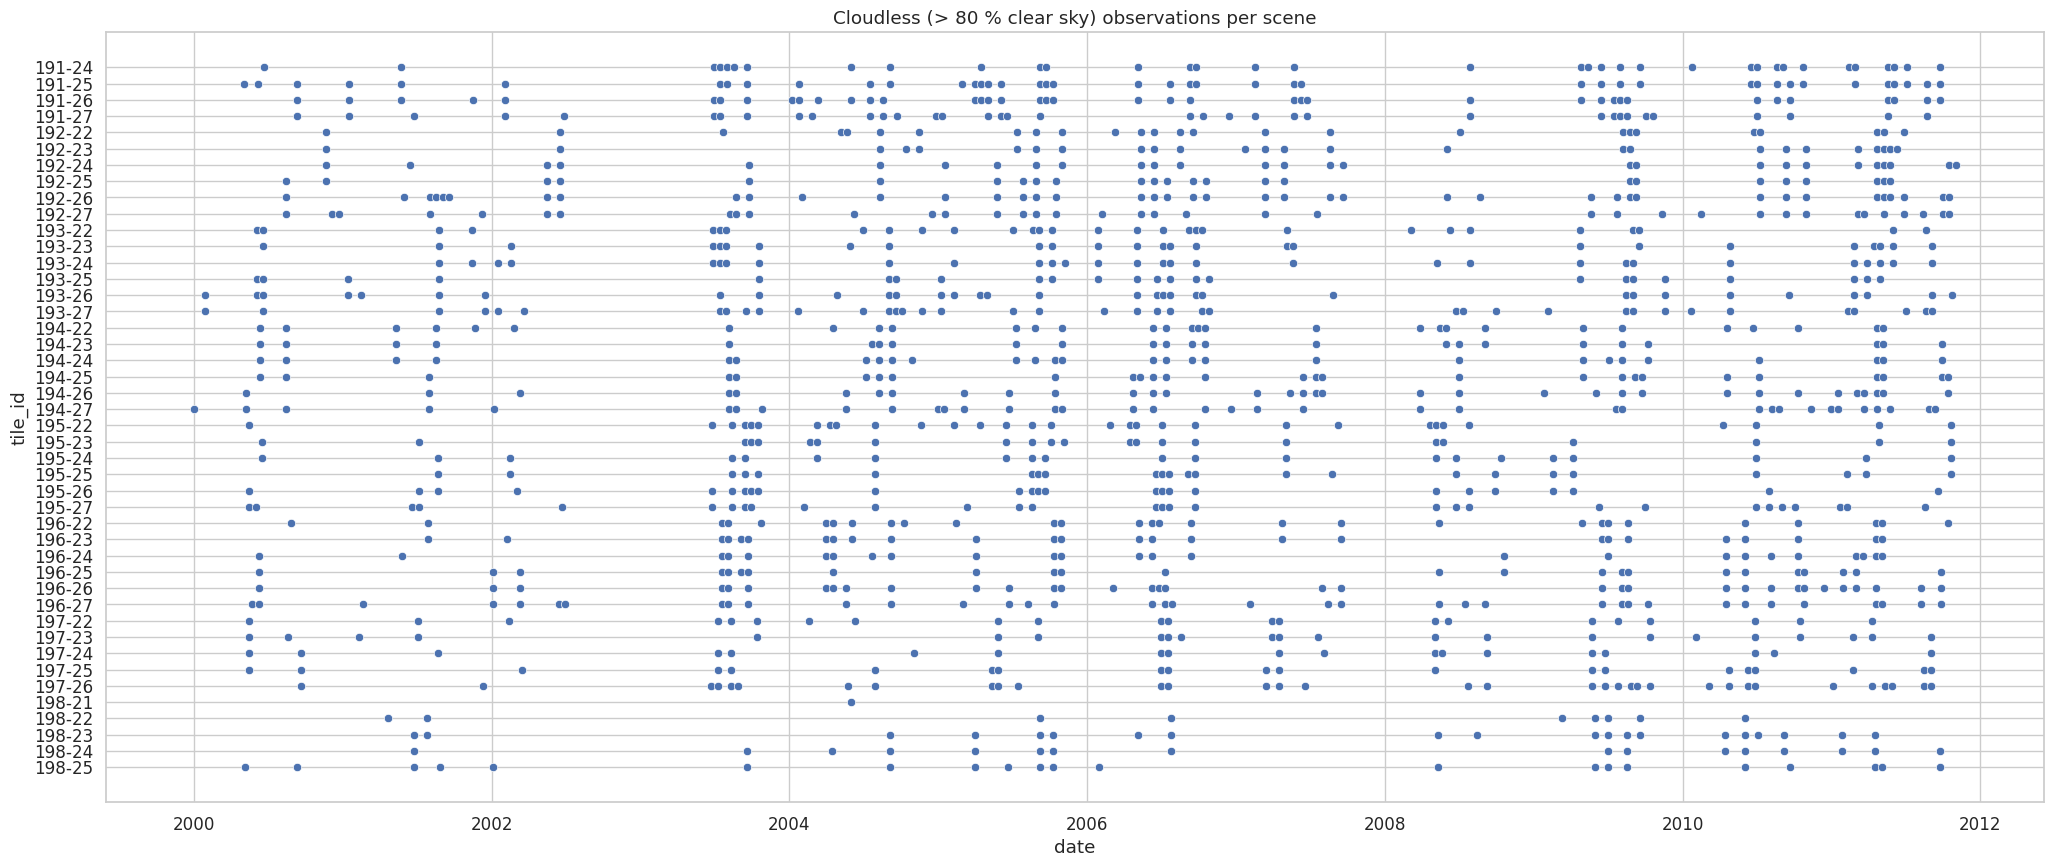

In [13]:
ax = sns.scatterplot(l5_df[l5_df['CLOUD_COVER'] < 20], x='date', y='tile_id')
ax.set_title("Cloudless (> 80 % clear sky) observations per scene")

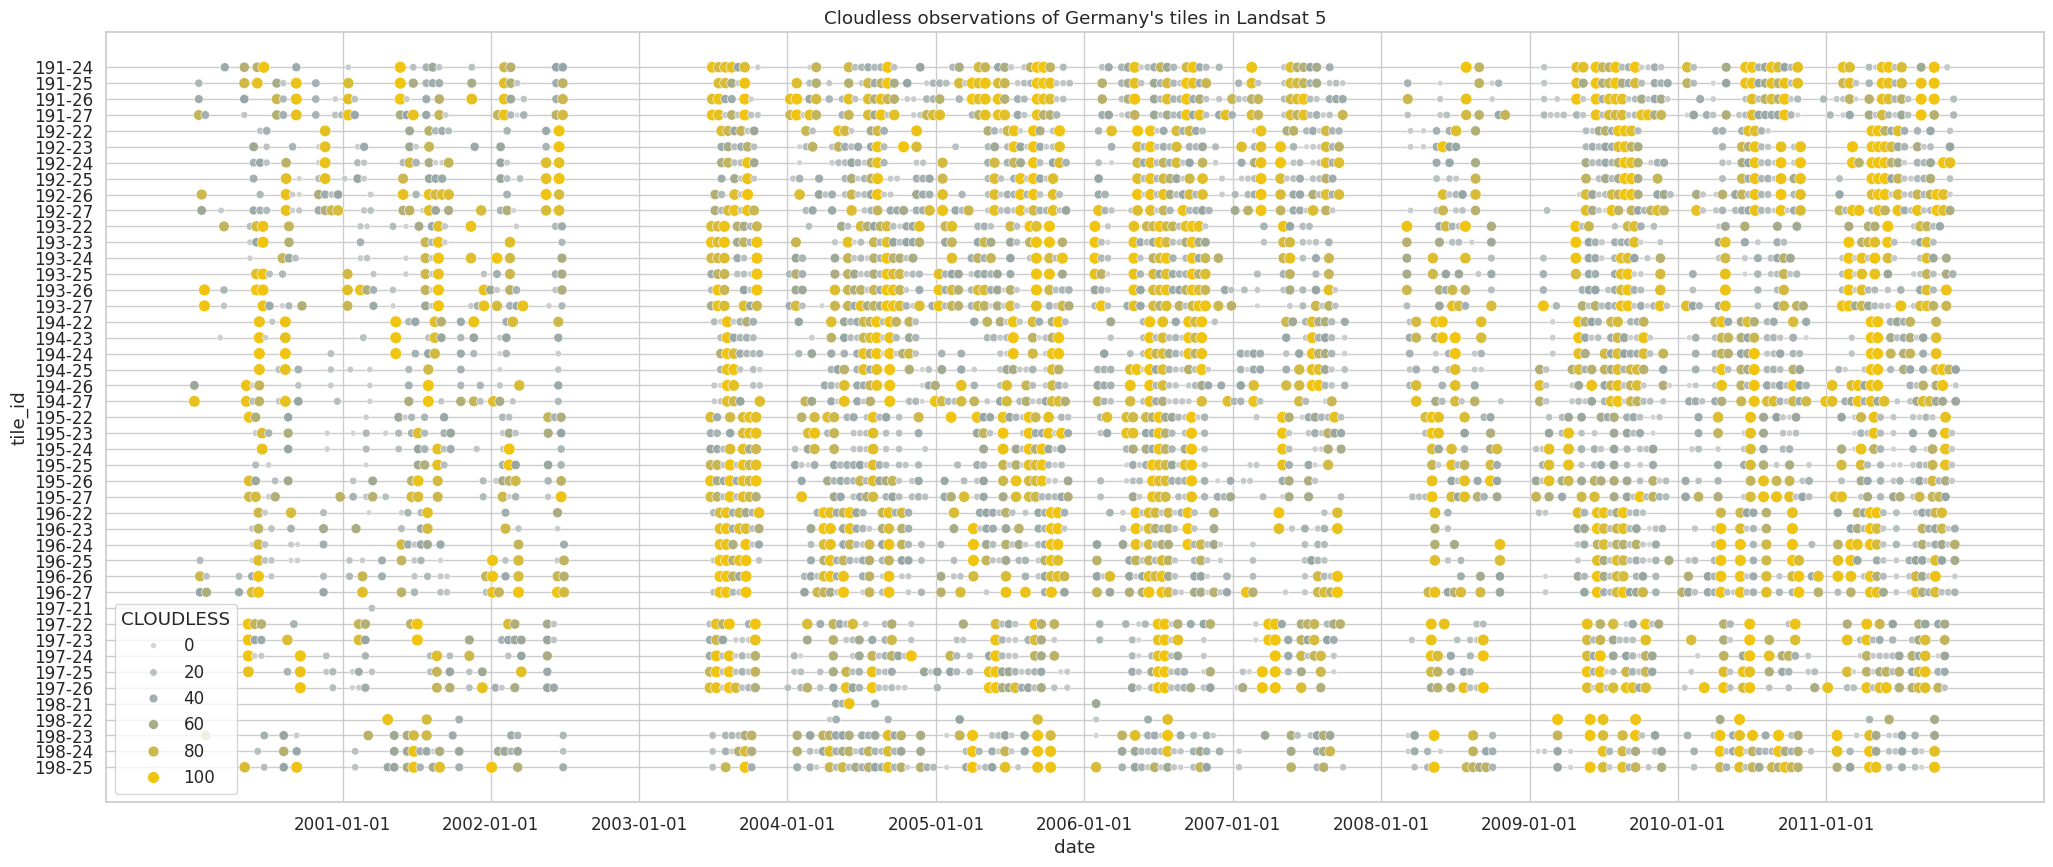

In [14]:
ax = sns.scatterplot(l5_df, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", palette=custom_palette)

years = pd.date_range(l5_df['date'].min(), l5_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 5")
plt.show()

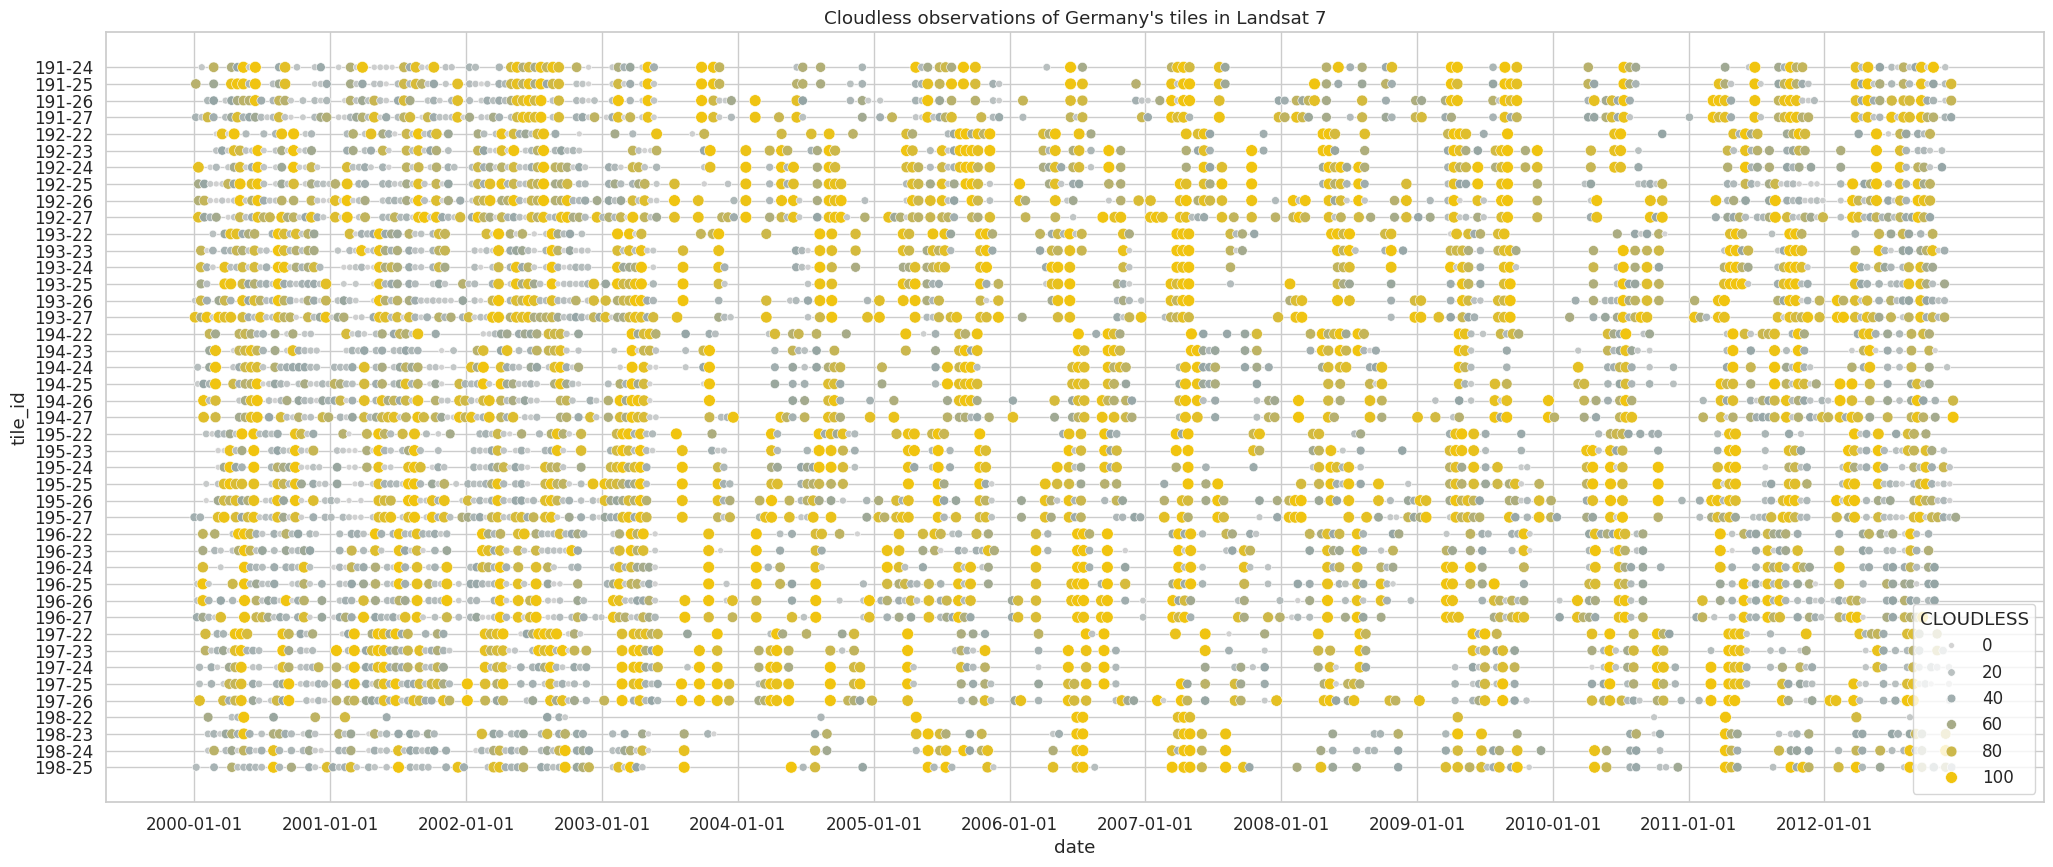

In [15]:
ax = sns.scatterplot(l7_df, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", palette=custom_palette)

years = pd.date_range(l7_df['date'].min(), l7_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 7")
plt.show()